# 21_因果推断基础-倾向评分：从处理预测到协变量平衡

## Notebook 使用说明

建议先阅读《03. 因果图、混杂与识别假设》和《04. 回归调整与标准化》。本篇需要 NumPy、pandas、Matplotlib 和 statsmodels。缺少依赖时，可在当前 Python 环境安装：`python -m pip install numpy pandas matplotlib statsmodels`。

本篇主要依据参考资料 [1] 第 11.1、11.3 节与 [2] 第 5.3–5.4 节。离散概率表、主模拟和练习数据都是为讲清这些方法另设的教学构造，不是原书的实证数据。预测指标对照、标准化均值差图和程序核对是本篇的实现补充，会在对应位置说明。

数据和图形都由代码生成，不需要下载文件，也不依赖前面 Notebook 的变量或 `notebook_support.py`。沿用第三、四篇的总体视角，目标为 $E[Y(1)-Y(0)]$。重复模拟会重新生成研究对象；本篇不把分层后的观察性数据直接当作真正的分层随机试验来报告置信区间。

代码输出和图形均保存在 Notebook 中。重新运行请使用 Restart Kernel and Run All Cells；下文解释对应默认参数，修改参数后以新的输出为准。

In [1]:
# 环境初始化：本篇不读取外部数据，单独放在一个文件夹中也可以运行。
import os
import sys
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import statsmodels
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationWarning

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS,
    "axes.unicode_minus": False,
    "figure.dpi": 100,
    "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

SEED_DATA = 42
SEED_VALIDATION = 2026
SEED_REPEAT = 2027
SEED_SELECTION = 2028
SEED_SELECTION_VALIDATION = 2029
SEED_HIDDEN = 2030
N_MAIN = 3000
N_VALIDATION = 10000
K_MAIN = 10
N_REPEATS = 500
SAMPLE_SIZES = (800, 3200)
K_REPEATED = (5, 10, 20)

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"statsmodels {statsmodels.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
statsmodels 0.14.6


上一篇拟合的是“接受或不接受处理时，结果各是多少”。现在换个方向：先不看结果，只研究“什么样的人更容易接受处理”。

比如，同样是参加辅导，有人因为基础较差被推荐参加，有人因为时间安排方便参加。我们可以用这些处理前信息，预测一个人参加辅导的概率。这个概率就是下面要用的倾向评分。

但把参加者预测得很准，还不够。后面要拿评分相近的参加者与未参加者作比较，因此还得检查：分层以后，两组的基础情况到底有没有变得接近？

## 理论基础

### 1. 倾向评分是什么？

仍用 $T\in\{0,1\}$ 表示处理，$X$ 表示选定的处理前调整变量，$Y$ 表示结局。在条件可忽略性的分析框架下，定义：

$$
e(X)=P(T=1\mid X).
$$

这里的 $e(X)$ 是一个概率，不是处理效应，也不是分类后得到的 0 或 1。两个人都得到 0.7，表示他们在所建模的分配机制下有相同的处理概率；不表示他们必定接受处理，更不表示处理对他们有相同作用。[1，第 11.1 节；2，第 5.3 节]

与上一篇对照：结果回归估计 $E[Y\mid T,X]$，倾向评分模型估计 $P(T=1\mid X)$。后者拟合时不把 $Y$ 放进自变量，也不把处理后的指标混入 $X$。

一个符号说明：Ding 的定义 11.1 先写出更一般的 $P(T=1\mid X,Y(1),Y(0))$，再在强可忽略性下化为 $P(T=1\mid X)$。本篇使用后一个形式；第二本书用 $D$ 表示处理、$p(X)$ 表示这个概率，这里统一写作 $T,e(X)$。

### 2. 为什么一个概率可以代替很多列变量？

真实倾向评分有一个平衡性质：

$$
T\perp\!\!\!\perp X\mid e(X).
$$

这句话比较的是分布：在同一个真实评分水平内，处理组和对照组的 $X$ 分布相同，不要求某两个人的每一列特征逐项相等。[1，定理 11.3]

关键计算很短。因为 $e(X)$ 本来就是 $X$ 的函数，

$$
P(T=1\mid X,e(X))=P(T=1\mid X)=e(X),
$$

而迭代期望给出

$$
P(T=1\mid e(X))
=E[E[T\mid X]\mid e(X)]
=E[e(X)\mid e(X)]=e(X).
$$

给定评分后，额外知道 $X$ 不再改变处理概率。这就得到上面的条件独立关系。[1，定理 11.3 的证明]

### 3. 平衡性质与因果解释，是两件事

上面的平衡性质只涉及 $X,T$，不需要对潜在结局作假设。但要从这里推到因果效应，还要有

$$
T\perp\!\!\!\perp\{Y(1),Y(0)\}\mid X.
$$

在这个假设下，才进一步得到

$$
T\perp\!\!\!\perp\{Y(1),Y(0)\}\mid e(X).
$$

再结合一致性、无干扰与重叠 $0<e(X)<1$，就可以写出：

$$
\tau=E\!\left[
E\{Y\mid T=1,e(X)\}-E\{Y\mid T=0,e(X)\}
\right].
$$

这就是把上一篇的标准化公式，从对 $X$ 条件化改为对评分条件化。它没有替我们证明“所有混杂都已经测到了”。[1，定理 11.1、11.3；2，定理 5.4.1]

实际使用的 $\widehat e(X)$ 还要从有限数据估计。模型错设、抽样误差以及后面的粗分层，都可能让平衡只近似成立。不能把关于真实 $e(X)$ 的定理，直接套到任意预测分数上。

### 4. 评分分层后，怎样得到总体效应？

将评分按全体样本的分位数分成 $K$ 层。设第 $k$ 层有 $n_k$ 人，其中 $n_{k1}$ 人接受处理、$n_{k0}$ 人未接受处理。先算层内均值差，再按全体人数比例平均：

$$
\widehat\tau_{\mathrm{strat}}
=\sum_{k=1}^{K}\frac{n_k}{n}
\left(\overline Y_{k1}-\overline Y_{k0}\right).
$$

这里仍然是“同一个目标人群、两次平均”。只有各层人数相同，才可以直接对层内差值等权平均。[1，第 11.1.2 节]

要区分同一个评分与同一个评分区间。即使真实评分已知，落在 0.1–0.3 内的人，其处理概率仍不完全相同。固定分成五层或十层，不是消除混杂的定理。层数太少会留下差异，太多又容易出现缺少某个处理组的层。[1，第 11.1.2 节]

降维也不等于线性化。即使真实评分已知，结局与评分的条件均值关系仍可能非线性。直接拟合 `Y ~ T + e(X)` 再读取处理系数，还会额外限制结果模型；它不等价于任意形式的评分条件化。[2，第 5.4 节]

## 完整案例一：四种人，三个评分

### 1. 先用概率表看清平衡性质

设两个处理前变量 $X_1,X_2$ 都取 0 或 1，四种组合各占总体的四分之一。人为指定

$$
e(X)=0.2+0.3(X_1+X_2).
$$

这样，$(X_1,X_2)=(1,0)$ 和 $(0,1)$ 都有评分 0.5，虽然两人的特征并不相同。

下面给出完整总体的概率表，不是一次抽样的人数表。为了同时核对效应计算，另设条件均值 $\mu_0(X)=10+2X_1+4X_2$、$\mu_1(X)=\mu_0(X)+2+X_1$，并假定处理只按给定的 $e(X)$ 生成。这个构造满足所需的条件可忽略性。

In [2]:
toy = pd.DataFrame({
    "X1": [0, 0, 1, 1],
    "X2": [0, 1, 0, 1],
    "P(X)": [0.25] * 4,
})
toy["e(X)"] = 0.2 + 0.3 * (toy["X1"] + toy["X2"])
toy["P(X,T=1)"] = toy["P(X)"] * toy["e(X)"]
toy["P(X,T=0)"] = toy["P(X)"] * (1 - toy["e(X)"])
toy["mu0"] = 10 + 2 * toy["X1"] + 4 * toy["X2"]
toy["mu1"] = toy["mu0"] + 2 + toy["X1"]
display(toy.round(3))

# 比如，在 e(X)=0.5 内，分别用两组的联合概率归一化。
mid = toy.loc[toy["e(X)"] == 0.5].copy()
mid["P(X | T=1,e=0.5)"] = mid["P(X,T=1)"] / mid["P(X,T=1)"].sum()
mid["P(X | T=0,e=0.5)"] = mid["P(X,T=0)"] / mid["P(X,T=0)"].sum()
display(mid[["X1", "X2", "P(X | T=1,e=0.5)", "P(X | T=0,e=0.5)"]])

,X1,X2,P(X),e(X),"P(X,T=1)","P(X,T=0)",mu0,mu1
0,0,0,0.25,0.2,0.050,0.200,10,12
1,0,1,0.25,0.5,0.125,0.125,14,16
2,1,0,0.25,0.5,0.125,0.125,12,15
3,1,1,0.25,0.8,0.200,0.050,16,19


,X1,X2,"P(X | T=1,e=0.5)","P(X | T=0,e=0.5)"
1,0,1,0.5,0.5
2,1,0,0.5,0.5


在评分 0.5 内，两种特征组合在处理组各占一半，在对照组也各占一半。这是完整分布的平衡，不只是某个均值碰巧相同。

### 2. 对评分层作同一种标准化

把三个评分水平当作三层，分别算两组的条件均值。此时没有估计评分，也没有把不同的真实评分合并到同一层，所以可以精确核对公式。

In [3]:
toy_rows = []
for score, part in toy.groupby("e(X)", sort=True):
    mu0 = np.average(part["mu0"], weights=part["P(X,T=0)"])
    mu1 = np.average(part["mu1"], weights=part["P(X,T=1)"])
    toy_rows.append({
        "e(X)": score, "总体层比例": part["P(X)"].sum(),
        "E[Y | T=0,e]": mu0, "E[Y | T=1,e]": mu1,
        "层内差": mu1 - mu0,
    })
toy_strata = pd.DataFrame(toy_rows).set_index("e(X)")
toy_stratified = np.average(toy_strata["层内差"], weights=toy_strata["总体层比例"])
toy_truth = np.average(toy["mu1"] - toy["mu0"], weights=toy["P(X)"])
toy_raw = (np.average(toy["mu1"], weights=toy["P(X,T=1)"])
           - np.average(toy["mu0"], weights=toy["P(X,T=0)"]))
display(toy_strata.round(3))
display(pd.Series({
    "未分层的观察均值差": toy_raw,
    "按真实评分分层": toy_stratified,
    "直接由潜在均值计算的ATE": toy_truth,
}, name="效应").to_frame().round(3))
np.testing.assert_allclose(toy_stratified, toy_truth, atol=1e-12)

,总体层比例,"E[Y | T=0,e]","E[Y | T=1,e]",层内差
e(X),,,,
0.2,0.25,10.0,12.0,2.0
0.5,0.50,13.0,15.5,2.5
0.8,0.25,16.0,19.0,3.0


,效应
未分层的观察均值差,4.45
按真实评分分层,2.50
直接由潜在均值计算的ATE,2.50


原始差值是 4.45，按评分分层后是 2.5，与总体真值一致。三个层的比例是 0.25、0.50、0.25；中间层要占一半的权重。

这里只演示了一个已知分配概率的总体。接下来把概率当成未知，用观察数据拟合，再检查这种替代是否做得足够好。

## 完整案例二：先估计评分，再检查平衡

### 1. 数据生成规则

保留辅导的背景。$X_1,X_2$ 是两个连续的处理前指标，$X_3$ 是一个二元背景指标，彼此独立。下面的尺度与系数完全是教学设定，$Y$ 不限制在 0–100 分。

$$
\begin{aligned}
X_1,X_2&\sim\operatorname{Uniform}(-1,1),\quad X_3\sim\operatorname{Bernoulli}(0.5),\\
\eta(X)&=-0.4+X_1-0.5X_2+0.6X_3
+1.8(X_1^2-1/3)+1.2X_1X_2,\\
e(X)&=\operatorname{expit}\{\eta(X)\},\quad T\mid X\sim\operatorname{Bernoulli}\{e(X)\},\\
\mu_0(X)&=10+2X_1+1.5X_2+2X_3+6X_1^2+3X_1X_2,\\
\tau(X)&=2+0.5X_1+0.8X_3,\\
Y(0)&=\mu_0(X)+\varepsilon,\quad Y(1)=Y(0)+\tau(X),\quad\varepsilon\sim N(0,1).
\end{aligned}
$$

处理抽签使用的随机量与 $\varepsilon$ 独立，因此给定这三个 $X$ 后没有剩余混杂。$\eta(X)$ 在有界区间内，故两种处理均有正概率。总体 ATE 为 $2+0.5\times0+0.8\times0.5=2.4$。

程序将 $X,T$、观察结局和模拟真值分开返回。先用 $X,T$ 做评分和分层诊断，确定规则后再读取结局；真值仅用于教学核对。

In [4]:
def expit(value):
    """稳定计算 Logistic 概率。"""
    return np.exp(-np.logaddexp(0.0, -np.asarray(value, dtype=float)))


def make_observational_data(n: int, seed: int):
    """生成主案例；拟合所需的 X,T 与结局、真值分别返回。"""
    if isinstance(n, bool) or not isinstance(n, (int, np.integer)) or n < 20:
        raise ValueError("n 必须是至少为 20 的整数。")
    rng = np.random.default_rng(seed)
    x1 = rng.uniform(-1, 1, n)
    x2 = rng.uniform(-1, 1, n)
    x3 = rng.binomial(1, 0.5, n)
    eta = -0.4 + x1 - 0.5*x2 + 0.6*x3 + 1.8*(x1**2 - 1/3) + 1.2*x1*x2
    propensity = expit(eta)
    treatment = rng.binomial(1, propensity)
    error = rng.normal(0, 1, n)
    mu0 = 10 + 2*x1 + 1.5*x2 + 2*x3 + 6*x1**2 + 3*x1*x2
    effect = 2 + 0.5*x1 + 0.8*x3
    y0 = mu0 + error
    y1 = y0 + effect
    outcome = np.where(treatment == 1, y1, y0)
    design = pd.DataFrame({"X1": x1, "X2": x2, "X3": x3, "T": treatment})
    truth = {"propensity": propensity, "Y0": y0, "Y1": y1,
             "effect": effect, "population_ate": 2.4}
    return design, outcome, truth


def diagnostic_features(data):
    """检查原变量，也检查事先指定的平方项和交互项。"""
    h = data[["X1", "X2", "X3"]].astype(float).copy()
    h["X1²"] = h["X1"]**2
    h["X2²"] = h["X2"]**2
    h["X1×X2"] = h["X1"] * h["X2"]
    return h


design, outcome, truth = make_observational_data(N_MAIN, SEED_DATA)
t = design["T"].to_numpy()
H = diagnostic_features(design)
display(design.head(8))
display(design.groupby("T").agg(
    人数=("T", "size"), X1均值=("X1", "mean"),
    X2均值=("X2", "mean"), X3比例=("X3", "mean"),
).round(3))

,X1,X2,X3,T
0,0.547912,0.658442,0,0
1,-0.122243,0.188192,0,0
2,0.717196,-0.510291,1,1
3,0.394736,0.491350,0,0
4,-0.811645,-0.831038,0,1
5,0.951245,0.548836,0,1
6,0.522279,0.179970,1,1
7,0.572129,-0.778499,1,1


,人数,X1均值,X2均值,X3比例
T,,,,
0,1565,-0.14,0.046,0.444
1,1435,0.15,-0.092,0.576


### 2. 用 Logistic 回归估计处理概率

事先指定两个模型。它们用同样的三个原变量，区别在于是否表达非线性与交互关系：

| 模型 | 线性预测子中的项 |
|---|---|
| 仅主效应 | 截距、$X_1,X_2,X_3$ |
| 加二次与交互 | 截距、$X_1,X_2,X_3,X_1^2,X_1X_2$ |

这里的“主效应”是 Logistic 线性预测子的用语，不是说它估计出了某个因果主效应。第二个模型包含主模拟的真实评分形式，第一个故意漏掉二次项与交互项。这个比较不是根据后面估计出的 ATE 临时选模型。

生成式中的 $1.8(X_1^2-1/3)$ 在设计矩阵里展开为平方项与截距。因而第二个模型的真实截距是 $-0.4-1.8/3=-1.0$，不是 $-0.4$；这只是写法改变，并非模型改变。

沿用上一份的 statsmodels 二项 GLM。设计矩阵显式带截距，`predict` 返回概率；不把概率按 0.5 切成类别。[1，第 11.1.2 节；3，GLM 接口文档]

In [5]:
MODEL_NAMES = {"main": "仅主效应", "rich": "加二次与交互"}


def ps_matrix(data, specification: str):
    h = diagnostic_features(data)
    columns = {"main": ["X1", "X2", "X3"],
               "rich": ["X1", "X2", "X3", "X1²", "X1×X2"]}
    if specification not in columns:
        raise ValueError("specification 应为 'main' 或 'rich'。")
    matrix = h[columns[specification]].copy()
    matrix.insert(0, "截距", 1.0)
    return matrix


def fit_logistic(matrix, treatment):
    """仅拟合处理模型；遇到不可用的数据或分离时明确报错。"""
    D = np.asarray(matrix, dtype=float)
    z = np.asarray(treatment, dtype=float)
    if D.ndim != 2 or z.ndim != 1 or len(D) != len(z):
        raise ValueError("设计矩阵与一维处理向量必须行数一致。")
    if not np.isfinite(D).all() or not np.isfinite(z).all():
        raise ValueError("输入不能含缺失值或无穷值。")
    if not np.isin(z, [0, 1]).all() or len(np.unique(z)) != 2:
        raise ValueError("处理必须为 0/1，且两组都存在。")
    if len(z) <= D.shape[1] or np.linalg.matrix_rank(D) != D.shape[1]:
        raise ValueError("设计矩阵必须满列秩，且人数多于参数数目。")
    # 分离不能当作拟合成功；把这类警告转为异常，而不是隐藏它。
    with warnings.catch_warnings():
        warnings.simplefilter("error", PerfectSeparationWarning)
        result = sm.GLM(z, matrix, family=sm.families.Binomial()).fit(
            maxiter=100, tol=1e-10
        )
    if not result.converged or not np.isfinite(result.params).all():
        raise RuntimeError("处理模型没有正常收敛。")
    return result


models, scores = {}, {}
for specification, label in MODEL_NAMES.items():
    D = ps_matrix(design, specification)
    models[specification] = fit_logistic(D, t)
    scores[specification] = np.asarray(models[specification].predict(D))
coefficient_table = pd.concat(
    {MODEL_NAMES[s]: models[s].params for s in MODEL_NAMES}, axis=1
)
display(coefficient_table.round(4).fillna("未纳入"))

,仅主效应,加二次与交互
截距,-0.4214,-1.1320
X1,0.97,1.1130
X2,-0.4953,-0.4877
X3,0.6273,0.6333
X1²,未纳入,2.1620
X1×X2,未纳入,1.1144


### 3. 先看处理预测，但不在这里结束

下面另生成一份独立验证数据，只用来评价已经拟合好的处理模型。训练数据仍完整用于本篇的分层分析；这不是 DML 的交叉拟合。

作为实现补充，计算两个熟悉的预测指标：AUC 衡量接受处理的人是否倾向于得到更高的分数；Brier 分数是概率预测的均方误差：

$$
\mathrm{Brier}=\frac1m\sum_{i=1}^{m}(T_i-\widehat e_i)^2.
$$

AUC 越大表示排序区分越强，Brier 越小表示概率平方误差越小。代码直接用平均秩计算含并列值的 AUC，等价于比较所有处理—对照对并给平分记半分。这些指标不是平衡指标，更不是效应估计误差；后面会专门做一个反例。

In [6]:
def prediction_metrics(treatment, probability):
    """AUC 使用平均秩处理并列分数；Brier 不需要概率截断。"""
    z = np.asarray(treatment, dtype=float)
    p = np.asarray(probability, dtype=float)
    if z.ndim != 1 or p.shape != z.shape or len(z) == 0:
        raise ValueError("处理与概率应为等长、非空的一维向量。")
    if not np.isfinite(p).all() or np.any((p < 0) | (p > 1)):
        raise ValueError("概率必须有限且位于 [0,1]。")
    if not np.isin(z, [0, 1]).all() or len(np.unique(z)) != 2:
        raise ValueError("处理必须为 0/1，且两组都存在。")
    n1, n0 = int(z.sum()), int((1-z).sum())
    ranks = pd.Series(p).rank(method="average").to_numpy()
    auc = (ranks[z == 1].sum() - n1*(n1+1)/2) / (n1*n0)
    return {"AUC": float(auc), "Brier": float(np.mean((z-p)**2))}


validation_design, _, _ = make_observational_data(N_VALIDATION, SEED_VALIDATION)
validation_scores = {}
prediction_rows = []
for specification, label in MODEL_NAMES.items():
    p = np.asarray(models[specification].predict(ps_matrix(validation_design, specification)))
    validation_scores[specification] = p
    prediction_rows.append({"模型": label, **prediction_metrics(validation_design["T"], p)})
prediction_table = pd.DataFrame(prediction_rows).set_index("模型")
display(prediction_table.round(4))

,AUC,Brier
模型,,
仅主效应,0.6724,0.2268
加二次与交互,0.7403,0.2059


### 4. 检查评分分布与可比较范围

先画含二次项和交互项的估计评分，分处理组与对照组展示。直方图共用分箱，每组按自身人数归一化；不能因为某组人数多，就把更高的柱子误读为更大的概率密度。

两组的边际评分分布不必完全重合。更重要的是：某个区域是否几乎只有一组的人，以及稍后每一层能否找到两组。图中的长尾也提醒我们，概率很接近 0 或 1 的区域需要更仔细地检查。[1，第 11.1.2 节与图 11.1]

,人数,最小,中位数,最大,评分<0.1的人数,评分>0.9的人数
T,,,,,,
0,1565,0.1017,0.3480,0.9580,0,8
1,1435,0.1068,0.5751,0.9669,0,93


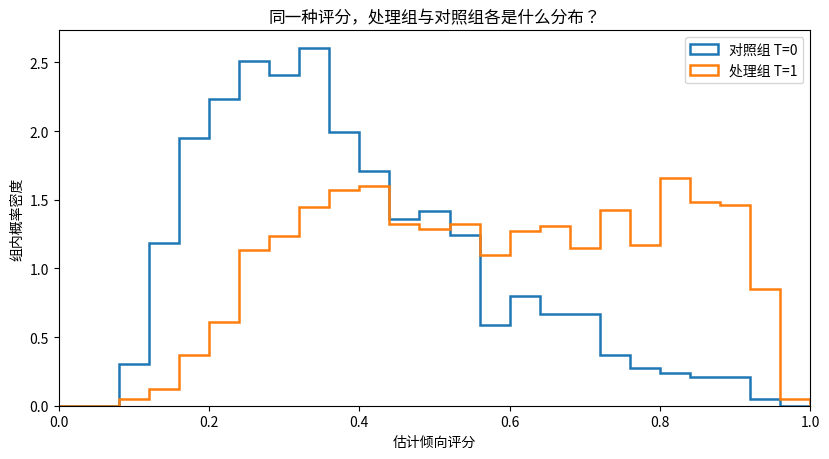

In [7]:
p_rich = scores["rich"]
score_summary = []
for treatment in (0, 1):
    p = p_rich[t == treatment]
    score_summary.append({"T": treatment, "人数": len(p), "最小": p.min(),
                          "中位数": np.median(p), "最大": p.max(),
                          "评分<0.1的人数": int((p < 0.1).sum()),
                          "评分>0.9的人数": int((p > 0.9).sum())})
display(pd.DataFrame(score_summary).set_index("T").round(4))

fig, ax = plt.subplots(figsize=(8.4, 4.7))
bins = np.linspace(0, 1, 26)
for treatment, label in [(0, "对照组 T=0"), (1, "处理组 T=1")]:
    ax.hist(p_rich[t == treatment], bins=bins, density=True,
            histtype="step", linewidth=1.8, label=label)
ax.set(xlabel="估计倾向评分", ylabel="组内概率密度",
       title="同一种评分，处理组与对照组各是什么分布？", xlim=(0, 1))
ax.legend()
fig.tight_layout()
plt.show()

### 5. 按全体评分分位数分层

这里预先使用十层。所有人的评分一起计算切点，不分别给处理组和对照组划分分位数。

重复评分有一个细节：不能为了凑够十层，把评分完全相同的人按行号拆开。下面合并重复切点，并报告实际层数；只有两个不同评分的数据，可能最后只有两层。若任何层没有某个处理组，效应计算返回缺失并说明原因，不删除该层后悄悄改成另一个目标人群。

In [8]:
def quantile_strata(probability, k: int):
    """按总体分位数分层；相同评分不拆开，层号连续并从 0 开始。"""
    p = np.asarray(probability, dtype=float)
    if p.ndim != 1 or len(p) == 0 or not np.isfinite(p).all():
        raise ValueError("评分应为非空、有限的一维向量。")
    if np.any((p < 0) | (p > 1)):
        raise ValueError("评分应在 [0,1] 范围内。")
    if isinstance(k, bool) or not isinstance(k, (int, np.integer)) or not 1 <= k <= len(p):
        raise ValueError("k 应为 1 到样本量之间的整数。")
    cutpoints = np.unique(np.quantile(p, np.arange(1, k) / k))
    labels = np.searchsorted(cutpoints, p, side="right")
    return np.unique(labels, return_inverse=True)[1]


def stratum_counts(treatment, labels):
    z = np.asarray(treatment)
    g = np.asarray(labels)
    if z.ndim != 1 or g.shape != z.shape or len(z) == 0:
        raise ValueError("处理与层号应为等长的非空一维向量。")
    if not np.isin(z, [0, 1]).all():
        raise ValueError("处理必须为 0/1。")
    if not np.issubdtype(g.dtype, np.integer) or not np.array_equal(np.unique(g), np.arange(g.max()+1)):
        raise ValueError("层号必须是从 0 开始的连续整数。")
    K = int(g.max()) + 1
    n0 = np.bincount(g[z == 0], minlength=K)
    n1 = np.bincount(g[z == 1], minlength=K)
    counts = pd.DataFrame({"n0": n0, "n1": n1, "n": n0+n1})
    counts["pi"] = counts["n"] / len(z)
    counts["两组齐全"] = (n0 > 0) & (n1 > 0)
    counts.index.name = "层号"
    return counts


strata = {s: quantile_strata(p, K_MAIN) for s, p in scores.items()}
main_counts = stratum_counts(t, strata["rich"])
score_ranges = pd.DataFrame({"层号": strata["rich"], "评分": p_rich}).groupby("层号")["评分"].agg(
    评分最小="min", 评分最大="max"
)
display(main_counts.join(score_ranges).round(4))
print(f"请求 {K_MAIN} 层，实际 {len(main_counts)} 层；最少的层内单组人数："
      f"{main_counts[['n0', 'n1']].to_numpy().min()}")

,n0,n1,n,pi,两组齐全,评分最小,评分最大
层号,,,,,,,
0,261,39,300,0.1,True,0.1017,0.2141
1,226,74,300,0.1,True,0.2146,0.2714
2,202,98,300,0.1,True,0.2716,0.3255
3,194,106,300,0.1,True,0.3256,0.3775
4,162,138,300,0.1,True,0.3775,0.4333
5,161,139,300,0.1,True,0.4337,0.5079
6,140,160,300,0.1,True,0.5080,0.5977
7,115,185,300,0.1,True,0.5979,0.7048
8,69,231,300,0.1,True,0.7063,0.8214


请求 10 层，实际 10 层；最少的层内单组人数：35


### 6. 标准化均值差：分层前后是否更接近？

原书图 11.2 把协变量当作“伪结局”，画调整后差值与区间。本篇沿用“先看 $X,T$，再看 $Y$”的检查顺序，但为便于不同量纲的变量放在同一张图上，采用下面明确规定的标准化均值差（SMD）。这是本篇的显示与计算约定，不是原图的置信区间。[1，第 11.3.2 节与图 11.2]

对每个待检查的变量或变换 $h_j(X)$，固定原始两组的尺度：

$$
s_j=\sqrt{\frac{s_{j1}^2+s_{j0}^2}{2}},\qquad
 d_{j,\mathrm{before}}=\frac{\bar h_{j1}-\bar h_{j0}}{s_j}.
$$

其中 $s_{j1}^2,s_{j0}^2$ 是未调整时两组的样本方差。分层后，用同一组目标层比例、同一个分母：

$$
d_{jk}=\frac{\bar h_{jk1}-\bar h_{jk0}}{s_j},\qquad
 d_{j,\mathrm{after}}=\sum_k\frac{n_k}{n}d_{jk}.
$$

分母不随调整方式改变，避免把尺度变化误当作平衡改善。除原变量外，也检查事先列出的平方项和交互项。

一个总体的有符号差值可能掩盖层间抵消。因此表里另外报告 $\sum_k(n_k/n)|d_{jk}|$ 和 $\max_k|d_{jk}|$，并画层内图。它们只是诊断量，不是 p 值，也不能从几个小数字推出完整联合分布已平衡。

In [9]:
def balance_diagnostics(features, treatment, labels=None):
    """分母固定在原始两组；同时保留汇总差与层内差，防止正负抵消。"""
    h = pd.DataFrame(features).astype(float)
    z = np.asarray(treatment)
    if z.ndim != 1 or len(h) != len(z) or not np.isfinite(h.to_numpy()).all():
        raise ValueError("特征必须有限，并与一维处理向量行数一致。")
    if not np.isin(z, [0, 1]).all() or min((z == 0).sum(), (z == 1).sum()) < 2:
        raise ValueError("处理必须为 0/1，原始每组至少两人。")
    scale = np.sqrt((h.loc[z == 1].var(ddof=1) + h.loc[z == 0].var(ddof=1)) / 2)
    if (scale <= 0).any():
        raise ValueError("存在原始两组内都没有变异的特征，SMD 分母为零。")
    raw = (h.loc[z == 1].mean() - h.loc[z == 0].mean()) / scale
    result = pd.DataFrame({"未调整SMD": raw})
    if labels is None:
        return result, None
    g = np.asarray(labels)
    counts = stratum_counts(z, g)
    if not counts["两组齐全"].all():
        raise ValueError("至少一层缺少处理组或对照组，不能汇总全体的平衡。")
    within = pd.DataFrame([
        (h.loc[(g == k) & (z == 1)].mean() - h.loc[(g == k) & (z == 0)].mean()) / scale
        for k in counts.index
    ], index=counts.index)
    pi = counts["pi"].to_numpy()
    result["分层后SMD"] = pi @ within.to_numpy()
    result["加权绝对层内差"] = pi @ np.abs(within.to_numpy())
    result["最大绝对层内差"] = np.abs(within.to_numpy()).max(axis=0)
    return result, within


balance_tables, within_tables = {}, {}
for specification in MODEL_NAMES:
    balance_tables[specification], within_tables[specification] = balance_diagnostics(
        H, t, strata[specification]
    )
display(pd.concat({MODEL_NAMES[s]: balance_tables[s] for s in MODEL_NAMES},
                  names=["评分模型", "变量"]).round(3))

未调整SMD  分层后SMD  加权绝对层内差  最大绝对层内差
评分模型   变量                                     
仅主效应   X1      0.514   0.008    0.306    0.418
       X2     -0.241  -0.016    0.420    0.557
       X3      0.265   0.016    0.162    0.340
       X1²     0.585   0.592    0.592    0.822
       X2²    -0.012  -0.061    0.143    0.471
       X1×X2   0.277   0.362    0.362    0.503
加二次与交互 X1      0.514   0.011    0.067    0.150
       X2     -0.241   0.011    0.126    0.319
       X3      0.265  -0.002    0.105    0.227
       X1²     0.585   0.021    0.062    0.129
       X2²    -0.012  -0.036    0.087    0.216
       X1×X2   0.277   0.017    0.105    0.450

默认数据中，仅主效应模型分层后的 $X_1,X_2,X_3$ 汇总 SMD 已经很小，但 $X_1^2$ 仍约为 0.59，$X_1X_2$ 约为 0.36。只看原变量的均值，会漏掉这个问题。

再看“加权绝对层内差”：仅主效应模型下 $X_1,X_2$ 的层内差并不小，只是在不同层出现了正负抵消。把多个均值汇总成一个点，仍然可能丢信息。

下面先画汇总差的绝对值。点越靠近零，表示这一个检查量越接近；图中不设“全部小于某个值就证明无混杂”的通行线。

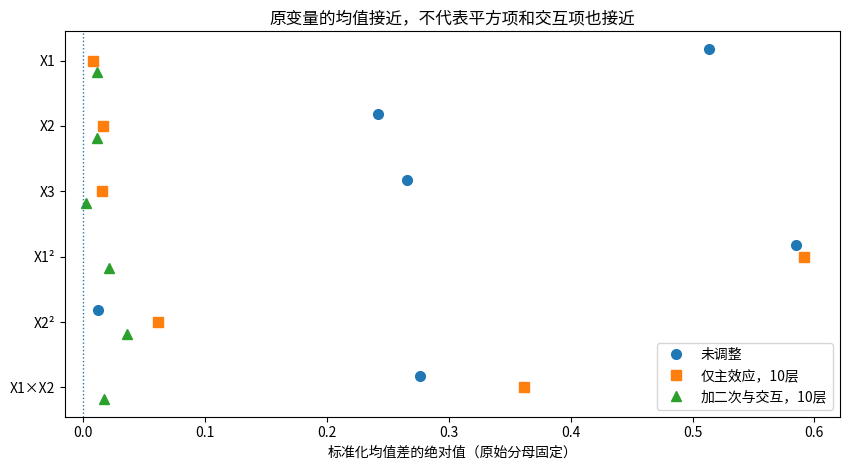

In [10]:
balance_plot = pd.DataFrame({
    "未调整": balance_tables["rich"]["未调整SMD"].abs(),
    "仅主效应，10层": balance_tables["main"]["分层后SMD"].abs(),
    "加二次与交互，10层": balance_tables["rich"]["分层后SMD"].abs(),
})
fig, ax = plt.subplots(figsize=(8.6, 4.8))
positions = np.arange(len(balance_plot))
for offset, (label, values), marker in zip(
    (-0.18, 0.0, 0.18), balance_plot.items(), ("o", "s", "^")
):
    ax.plot(values, positions + offset, marker, markersize=7, label=label)
ax.set_yticks(positions, balance_plot.index)
ax.invert_yaxis()
ax.set(xlabel="标准化均值差的绝对值（原始分母固定）",
       title="原变量的均值接近，不代表平方项和交互项也接近", xlim=(-0.015, None))
ax.axvline(0, linestyle=":", linewidth=1)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

### 7. 回到每一层看，避免只看汇总点

这次只画含二次项和交互项的模型，查看每一层、每一个变量的 $|d_{jk}|$。色条对应的数值越大，残留的层内差越大。

十层中的比较人数并不相同，尤其高评分层的对照人数较少，单个格子可能因抽样波动偏大。因此要把图与人数表一起读，不能把它当成六十个显著性检验。

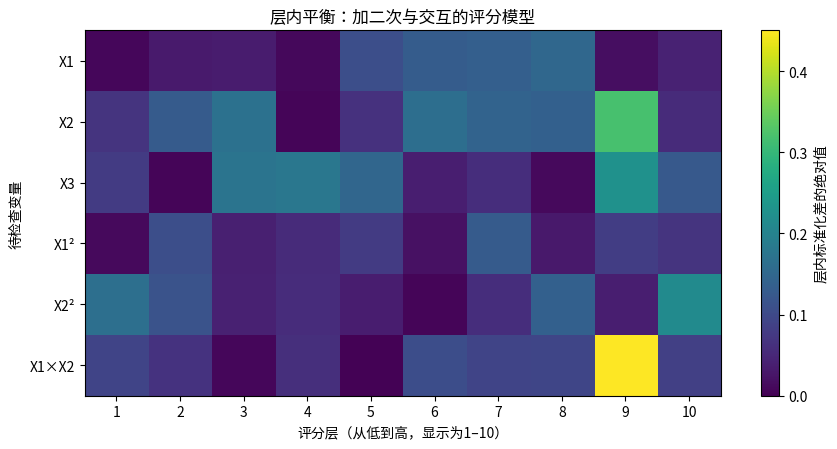

In [11]:
within_abs = within_tables["rich"].abs()
fig, ax = plt.subplots(figsize=(9.0, 4.6))
image = ax.imshow(within_abs.to_numpy().T, aspect="auto", vmin=0)
ax.set_xticks(np.arange(len(within_abs)), np.arange(1, len(within_abs)+1))
ax.set_yticks(np.arange(len(within_abs.columns)), within_abs.columns)
ax.set(xlabel="评分层（从低到高，显示为1–10）", ylabel="待检查变量",
       title="层内平衡：加二次与交互的评分模型")
fig.colorbar(image, ax=ax, label="层内标准化差的绝对值")
fig.tight_layout()
plt.show()

### 8. 分层规则确定以后，再读取结局

到这里，两个模型、待检查的变换和十层规则都已给出，没有根据 $Y$ 的效应值反复搜索。现在才用观察结局计算层内差与标准化平均。

下面也列出“真实评分”作为模拟参考。它不是实际数据可以调用的第三个模型；即使使用它，粗分十层仍可能留下差异。

In [12]:
def stratified_difference(treatment, outcome_values, labels):
    """全体目标的分层均值差；缺少任何一层的比较组时返回 NaN。"""
    z = np.asarray(treatment, dtype=float)
    y = np.asarray(outcome_values, dtype=float)
    g = np.asarray(labels)
    if y.ndim != 1 or y.shape != z.shape or not np.isfinite(y).all():
        raise ValueError("结局应为有限的一维向量，且与处理等长。")
    counts = stratum_counts(z, g)
    table = counts.copy()
    if not counts["两组齐全"].all():
        return np.nan, table
    K = len(counts)
    mean0 = np.bincount(g, weights=(1-z)*y, minlength=K) / counts["n0"].to_numpy()
    mean1 = np.bincount(g, weights=z*y, minlength=K) / counts["n1"].to_numpy()
    table["Y均值0"], table["Y均值1"] = mean0, mean1
    table["层内差"] = mean1-mean0
    table["对总体的贡献"] = table["pi"] * table["层内差"]
    return float(table["对总体的贡献"].sum()), table


y = outcome.copy()
main_estimate, outcome_by_stratum = stratified_difference(t, y, strata["rich"])
display(outcome_by_stratum.round(4))

raw_estimate = y[t == 1].mean() - y[t == 0].mean()
main_effect_rows = [{"方法": "不调整", "估计": raw_estimate}]
for specification, label in MODEL_NAMES.items():
    estimate, _ = stratified_difference(t, y, strata[specification])
    main_effect_rows.append({"方法": f"{label}，10层", "估计": estimate})
true_score_strata = quantile_strata(truth["propensity"], K_MAIN)
oracle_estimate, _ = stratified_difference(t, y, true_score_strata)
main_effect_rows.append({"方法": "真实评分，10层（模拟参考）", "估计": oracle_estimate})
main_effect_table = pd.DataFrame(main_effect_rows).set_index("方法")
main_effect_table["与总体ATE=2.4之差"] = main_effect_table["估计"]-truth["population_ate"]
display(main_effect_table.round(4))

,n0,n1,n,pi,两组齐全,Y均值0,Y均值1,层内差,对总体的贡献
层号,,,,,,,,,
0,261,39,300,0.1,True,11.0359,13.0569,2.0210,0.2021
1,226,74,300,0.1,True,11.3616,13.4223,2.0607,0.2061
2,202,98,300,0.1,True,11.3086,13.2151,1.9065,0.1906
3,194,106,300,0.1,True,11.3073,13.6595,2.3522,0.2352
4,162,138,300,0.1,True,12.0284,14.7234,2.6950,0.2695
5,161,139,300,0.1,True,12.1120,14.7400,2.6280,0.2628
6,140,160,300,0.1,True,12.9579,15.3755,2.4176,0.2418
7,115,185,300,0.1,True,14.0006,16.7954,2.7949,0.2795
8,69,231,300,0.1,True,14.9038,18.2691,3.3653,0.3365


,估计,与总体ATE=2.4之差
方法,,
不调整,4.4944,2.0944
仅主效应，10层,3.8418,1.4418
加二次与交互，10层,2.5233,0.1233
真实评分，10层（模拟参考）,2.5640,0.1640


这一次，不调整约为 4.49，仅主效应分层约为 3.84，加二次与交互约为 2.52。两种 Logistic 模型都能运行，但它们留下的协变量差异不同，最终的效应也不同。

真实评分十层的结果约为 2.56，没有恰好等于 2.4。有限样本中既有随机波动，也有粗分层造成的误差。不能用一次更接近真值，就断言某一种估计评分优于真实评分。

## 进一步分析

### 1. 多分几层，能解决什么问题？

保持同一份数据和已经拟合的评分不变，只改变分层数，观察效应与层内人数。下面的试验用于说明层数的影响，不根据哪一个估计更接近模拟真值来确定实际分析的层数。

实际K  最少单组人数  缺组层数   ATE估计
评分         请求K                           
仅主效应       2      2     520     0  4.0244
           5      5     171     0  3.8779
           10    10      67     0  3.8418
           20    20      27     0  3.8302
           40    40      12     0  3.8343
           100  100       2     0  3.8701
加二次与交互     2      2     455     0  3.3793
           5      5     104     0  2.6978
           10    10      35     0  2.5233
           20    20      16     0  2.4917
           40    40       5     0  2.4914
           100  100       0     1     NaN
真实评分（模拟参考） 2      2     456     0  3.4014
           5      5     102     0  2.7383
           10    10      35     0  2.5640
           20    20      16     0  2.5396
           40    40       7     0  2.5137
           100  100       1     0  2.5172

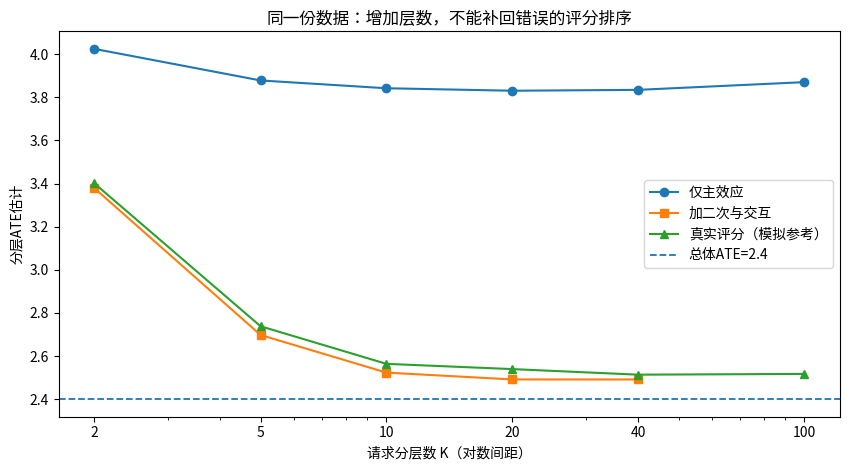

In [13]:
K_TRIALS = (2, 5, 10, 20, 40, 100)
score_choices = {MODEL_NAMES[s]: scores[s] for s in MODEL_NAMES}
score_choices["真实评分（模拟参考）"] = truth["propensity"]
k_records = []
for label, probability in score_choices.items():
    for k in K_TRIALS:
        g = quantile_strata(probability, k)
        estimate, table = stratified_difference(t, y, g)
        k_records.append({
            "评分": label, "请求K": k, "实际K": len(table),
            "最少单组人数": int(table[["n0", "n1"]].to_numpy().min()),
            "缺组层数": int((~table["两组齐全"]).sum()), "ATE估计": estimate,
        })
k_results = pd.DataFrame(k_records)
display(k_results.set_index(["评分", "请求K"]).round(4))

fig, ax = plt.subplots(figsize=(8.6, 4.8))
for (label, group), marker in zip(k_results.groupby("评分", sort=False), ("o", "s", "^")):
    # NaN 保留；缺组的计算不画点，也不把缺组层删掉后重算。
    ax.plot(group["请求K"], group["ATE估计"], marker=marker, label=label)
ax.axhline(truth["population_ate"], linestyle="--", linewidth=1.3, label="总体ATE=2.4")
ax.set(xscale="log", xlabel="请求分层数 K（对数间距）", ylabel="分层ATE估计",
       title="同一份数据：增加层数，不能补回错误的评分排序")
ax.set_xticks(K_TRIALS, [str(k) for k in K_TRIALS])
ax.legend()
fig.tight_layout()
plt.show()

仅主效应模型即使分成很多层，仍围绕偏高的数值。漏掉的结构没有因分层变细而自动补回来。较合适的评分能从细分层中受益，但也开始出现每层对照人数很少的问题；默认数据中，含二次与交互的模型分为 100 层时，有一层缺少某个处理组，表里保留为 NaN。

### 2. 重新生成多份数据，分开看偏差与波动

对两个样本量，各重新生成 500 份数据。每一份都从头估计评分、计算分位数、形成层内差；再与同一份数据的真实评分作对照。分层数事先固定为 5、10、20，不在循环里根据结局挑选。

表中 SD 是估计量跨模拟的经验标准差，RMSE 是相对于总体 ATE 的均方根误差，MCSE 是模拟平均值的标准误。它们都不是某一次真实研究的效应标准误。缺组的模拟保留并计数；有缺组时，其余统计量仅针对能够完整计算的重复，不能冒充无条件性能。

Ding 第 11.1.2 节单独讨论了分层推断的困难：直接套用分层随机试验标准误会忽略评分估计，整套程序 Bootstrap 的理论也不能在这里直接保证。因此本篇用重复模拟展示不确定性，不把上一份的 Bootstrap 区间机械搬过来。[1，第 11.1.2 节]

In [14]:
repeat_rng = np.random.default_rng(SEED_REPEAT)
repeat_records = []
for n in SAMPLE_SIZES:
    for repetition in range(N_REPEATS):
        seed = int(repeat_rng.integers(0, 2**32-1))
        d, y_repeat, tr = make_observational_data(n, seed)
        z = d["T"].to_numpy()
        repeat_records.append({
            "n": n, "评分": "不调整", "K": 1, "重复": repetition,
            "估计": y_repeat[z == 1].mean()-y_repeat[z == 0].mean(),
        })
        p_repeat = {}
        for specification, label in MODEL_NAMES.items():
            D = ps_matrix(d, specification)
            p_repeat[label] = np.asarray(fit_logistic(D, z).predict(D))
        p_repeat["真实评分（模拟参考）"] = tr["propensity"]
        for label, probability in p_repeat.items():
            for k in K_REPEATED:
                estimate, _ = stratified_difference(z, y_repeat, quantile_strata(probability, k))
                repeat_records.append({"n": n, "评分": label, "K": k,
                                       "重复": repetition, "估计": estimate})
repeat_results = pd.DataFrame(repeat_records)


def summarize_repeats(values):
    values = np.asarray(values, dtype=float)
    valid = values[np.isfinite(values)]
    if len(valid) < 2:
        raise RuntimeError("有效重复不足，不能计算经验标准差。")
    errors = valid-truth["population_ate"]
    sd = valid.std(ddof=1)
    return {"有效次数": len(valid), "缺组次数": len(values)-len(valid),
            "平均估计": valid.mean(), "Bias": errors.mean(), "SD": sd,
            "RMSE": np.sqrt(np.mean(errors**2)), "MCSE": sd/np.sqrt(len(valid))}


repeat_summary_rows = []
for (n, label, k), group in repeat_results.groupby(["n", "评分", "K"], sort=False):
    repeat_summary_rows.append({"n": n, "评分": label, "K": k,
                                **summarize_repeats(group["估计"])})
repeat_summary = pd.DataFrame(repeat_summary_rows).set_index(["n", "评分", "K"]).sort_index()
display(repeat_summary.round(4))
assert len(repeat_results) == len(SAMPLE_SIZES)*N_REPEATS*(1+len(score_choices)*len(K_REPEATED))

有效次数  缺组次数    平均估计    Bias      SD    RMSE    MCSE
n    评分         K                                                     
800  不调整        1    500     0  4.2476  1.8476  0.2181  1.8604  0.0098
     仅主效应       5    500     0  3.6355  1.2355  0.1663  1.2467  0.0074
                10   500     0  3.6010  1.2010  0.1685  1.2127  0.0075
                20   500     0  3.5842  1.1842  0.1730  1.1968  0.0077
     加二次与交互     5    500     0  2.6136  0.2136  0.1147  0.2424  0.0051
                10   500     0  2.4747  0.0747  0.1037  0.1277  0.0046
                20   498     2  2.4222  0.0222  0.1069  0.1091  0.0048
     真实评分（模拟参考） 5    500     0  2.6179  0.2179  0.1631  0.2721  0.0073
                10   500     0  2.4785  0.0785  0.1496  0.1688  0.0067
                20   496     4  2.4259  0.0259  0.1481  0.1502  0.0066
3200 不调整        1    500     0  4.2537  1.8537  0.1010  1.8565  0.0045
     仅主效应       5    500     0  3.6521  1.2521  0.0785  1.2545  0.0035
                10   500     0  3.6197  1.2197  0.0778  1.2222  0.0035
                20   500     0  3.6073  1.2073  0.0771  1.2097  0.0034
     加二次与交互     5    500     0  2.6235  0.2235  0.0563  0.2305  0.0025
                10   500     0  2.4826  0.0826  0.0517  0.0974  0.0023
                20   500     0  2.4300  0.0300  0.0515  0.0595  0.0023
     真实评分（模拟参考） 5    500     0  2.6238  0.2238  0.0798  0.2375  0.0036
                10   500     0  2.4840  0.0840  0.0735  0.1115  0.0033
                20   500     0  2.4294  0.0294  0.0702  0.0761  0.0031

下面只画较大样本量下的三个评分方案；不调整结果保留在表中。点是模拟平均偏差，误差棒是正负一个经验 SD，表示单份研究的估计会有多大波动，不是均值的置信区间。

比较五层与二十层，可以看出真实评分也受粗分层影响。再比较两个样本量，可以检查：增加人数主要缩小了波动，还是连偏差也消失了？

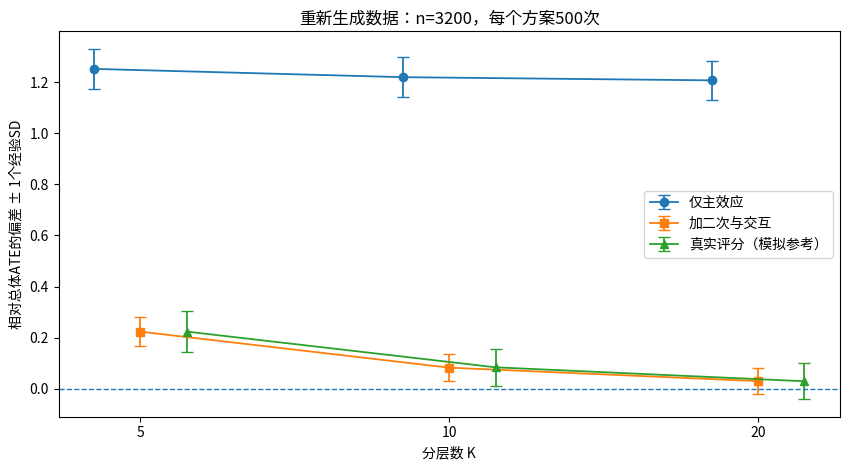

In [15]:
shown_n = SAMPLE_SIZES[-1]
positions = np.arange(len(K_REPEATED))
fig, ax = plt.subplots(figsize=(8.6, 4.8))
for offset, label, marker in zip((-0.15, 0.0, 0.15), score_choices, ("o", "s", "^")):
    group = repeat_summary.loc[(shown_n, label)].reindex(K_REPEATED)
    ax.errorbar(positions+offset, group["Bias"], yerr=group["SD"],
                marker=marker, capsize=4, linewidth=1.3, label=label)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(positions, [str(k) for k in K_REPEATED])
ax.set(xlabel="分层数 K", ylabel="相对总体ATE的偏差 ± 1个经验SD",
       title=f"重新生成数据：n={shown_n}，每个方案{N_REPEATS}次")
ax.legend()
fig.tight_layout()
plt.show()

本例中，加二次与交互的评分和真实评分在分层变细后，平均偏差都变小；仅主效应模型仍有明显偏差。固定五层时，较大样本量下也保留了粗分层误差。

估计评分方案的经验波动有时比使用真实评分更小，并不矛盾。两种计算利用数据的方式不同，不能把“知道真实评分”理解成所有有限样本性能都必定更好。这里展示的是这套生成机制的结果；评分估计可能影响方差，也是原书提醒不要随意套标准误公式的原因。[1，第 11.1.2 节]

### 3. 反例：AUC 高的模型，为什么仍可能调整错？

再设一个更容易算清楚的教学例子。$C,R$ 是相互独立的二元处理前变量，各以一半概率取 1。$C$ 是影响后续成绩的基础情况，$R$ 是只影响能否参加辅导的行政安排。

$$
P(T=1\mid C,R)=0.05+0.15C+0.70R,\qquad
Y=10+8C+2T+\varepsilon.
$$

处理抽签与结局误差独立，总体效应为 2。这里 $C$ 对参加概率的影响小，对结局的影响却大；$R$ 很容易预测参加状态，但没有不经过 $T$ 的路径影响 $Y$。

预先比较仅用 $R$、仅用 $C$、用 $C,R,CR$ 的三个 Logistic 模型。这个反例由本篇另设，不是原书的实证结果。它具体展示“处理预测任务”与“选择充分调整变量”的区别；不是一般性的变量筛选规则。[1，第 11.3 节；2，第 11.3 节的变量角色讨论]

In [16]:
def make_selection_example(n: int, seed: int):
    rng = np.random.default_rng(seed)
    c = rng.binomial(1, 0.5, n)
    r = rng.binomial(1, 0.5, n)
    p = 0.05+0.15*c+0.70*r
    z = rng.binomial(1, p)
    y_selection = 10+8*c+2*z+rng.normal(0, 1, n)
    data = pd.DataFrame({"C": c, "R": r, "CR": c*r, "T": z})
    return data, y_selection


selection_design, selection_y = make_selection_example(8000, SEED_SELECTION)
selection_validation, _ = make_selection_example(10000, SEED_SELECTION_VALIDATION)
selection_specs = {"仅用R": ["R"], "仅用C": ["C"], "C、R与交互": ["C", "R", "CR"]}
selection_t = selection_design["T"].to_numpy()
selection_rows = []
for label, columns in selection_specs.items():
    D = sm.add_constant(selection_design[columns], has_constant="add")
    fitted = fit_logistic(D, selection_t)
    p = np.asarray(fitted.predict(D))
    D_val = sm.add_constant(selection_validation[columns], has_constant="add")
    p_val = np.asarray(fitted.predict(D_val))
    g = quantile_strata(p, 10)
    estimate, counts = stratified_difference(selection_t, selection_y, g)
    bal, _ = balance_diagnostics(selection_design[["C", "R"]], selection_t, g)
    selection_rows.append({
        "模型": label, **prediction_metrics(selection_validation["T"], p_val),
        "实际层数": len(counts), "C分层后SMD": bal.loc["C", "分层后SMD"],
        "R分层后SMD": bal.loc["R", "分层后SMD"], "ATE估计": estimate,
    })
selection_results = pd.DataFrame(selection_rows).set_index("模型")
display(selection_results.round(4))

,AUC,Brier,实际层数,C分层后SMD,R分层后SMD,ATE估计
模型,,,,,,
仅用R,0.8542,0.1246,2,0.5751,0.0000,4.3125
仅用C,0.5749,0.2435,2,0.0000,1.9569,2.0432
C、R与交互,0.8912,0.1191,4,0.0000,0.0000,2.0437


在这个构造中，对另一个变量求平均可得 $P(T=1\mid R)=0.125+0.70R$、$P(T=1\mid C)=0.40+0.15C$。两个单变量 Logistic 模型对各自的二元自变量都是饱和模型，问题不在于优化器没拟合好，而在于它们条件化的变量不同。

仅用 $R$ 的 AUC 很高，但它没有处理 $C$ 带来的混杂；仅用 $C$ 的 AUC 低得多，却可以在本例中构造合适的比较。三个模型同时列出后还能看到：不需要在“预测好”与“调整对”之间必然二选一，充分的模型可以兼顾两者。

仅用 $C$ 时，$R$ 仍不平衡。在这个明确设定的因果结构中，它不妨碍识别，因为给定 $C$ 后，$R$ 只改变处理概率，不改变潜在结局的分布。换成另一个因果图，不能照抄这一结论。

这里实际只有两个或四个不同评分，所以分层函数如实给出两层或四层，没有按行号强凑十层。AUC 均来自独立验证数据；图中的效应来自分析数据。

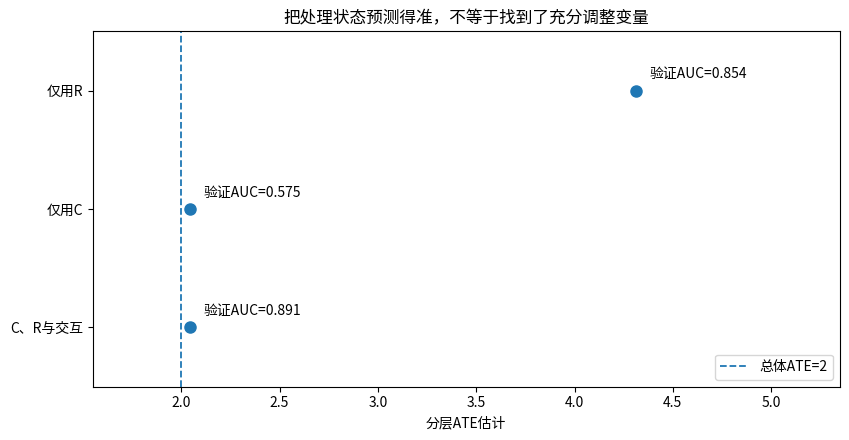

In [17]:
fig, ax = plt.subplots(figsize=(8.6, 4.5))
positions = np.arange(len(selection_results))
ax.plot(selection_results["ATE估计"], positions, "o", markersize=8)
for position, (label, row) in zip(positions, selection_results.iterrows()):
    ax.annotate(f"验证AUC={row['AUC']:.3f}",
                (row["ATE估计"], position), xytext=(10, 9),
                textcoords="offset points", fontsize=10)
ax.axvline(2, linestyle="--", linewidth=1.3, label="总体ATE=2")
ax.set_yticks(positions, selection_results.index)
ax.invert_yaxis()
ax.set(xlabel="分层ATE估计", title="把处理状态预测得准，不等于找到了充分调整变量",
       xlim=(1.55, 5.35), ylim=(2.5, -0.5))
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 练习

### 1. 把概率拉得更极端，AUC、分层与平衡会怎样？

回到主案例，保留已经拟合好的评分，不重新训练，作下面的严格单调变换：

$$
q(X)=\operatorname{expit}\{3\operatorname{logit}(\widehat e(X))\}.
$$

先判断哪些量会变，再运行代码：验证 AUC、Brier 分数、分层成员、分层 ATE，以及按这些层计算的 SMD。

因为变换保留排序，也保留并列关系，按分位数形成的层成员不会改变；AUC 也不会改变。但概率数值改变了，Brier 和概率校准可能变化。下面是对原书“分位数分层更依赖排序”这一说明的程序核对。[1，第 11.1.2 节]

参考实现：

In [18]:
def sharpen_probability(probability):
    p = np.asarray(probability, dtype=float)
    if not np.isfinite(p).all() or np.any((p <= 0) | (p >= 1)):
        raise ValueError("此变换要求概率严格位于 (0,1)。")
    return expit(3*(np.log(p)-np.log1p(-p)))


sharpened_main = sharpen_probability(scores["rich"])
sharpened_validation = sharpen_probability(validation_scores["rich"])
sharpened_strata = quantile_strata(sharpened_main, K_MAIN)
np.testing.assert_array_equal(sharpened_strata, strata["rich"])
changed_estimate, _ = stratified_difference(t, y, sharpened_strata)
changed_balance, _ = balance_diagnostics(H, t, sharpened_strata)
np.testing.assert_allclose(changed_estimate, main_estimate, atol=1e-12)
np.testing.assert_allclose(changed_balance, balance_tables["rich"], atol=1e-12)

transform_table = pd.DataFrame({
    "原估计概率": prediction_metrics(validation_design["T"], validation_scores["rich"]),
    "单调变换后": prediction_metrics(validation_design["T"], sharpened_validation),
}).T
transform_table["主数据分层ATE"] = [main_estimate, changed_estimate]
transform_table["层成员改变人数"] = [0, int((sharpened_strata != strata["rich"]).sum())]
display(transform_table.round(5))
np.testing.assert_allclose(transform_table["AUC"].iloc[0], transform_table["AUC"].iloc[1])

,AUC,Brier,主数据分层ATE,层成员改变人数
原估计概率,0.7403,0.20591,2.52331,0
单调变换后,0.7403,0.23925,2.52331,0


再用独立验证数据作一个分组校准图。横坐标是每个评分组的平均预测概率，纵坐标是实际处理比例；接近对角线表示这些组上的平均概率较一致，不能据此证明所有条件概率都估对了。

两套分数在这个例子里对应相同的分位数组，因此各点的纵坐标不变，横坐标却被拉开。分层所需要的排序信息，与逆概率加权需要的概率数值，不是同一层要求；后者留到下一篇。

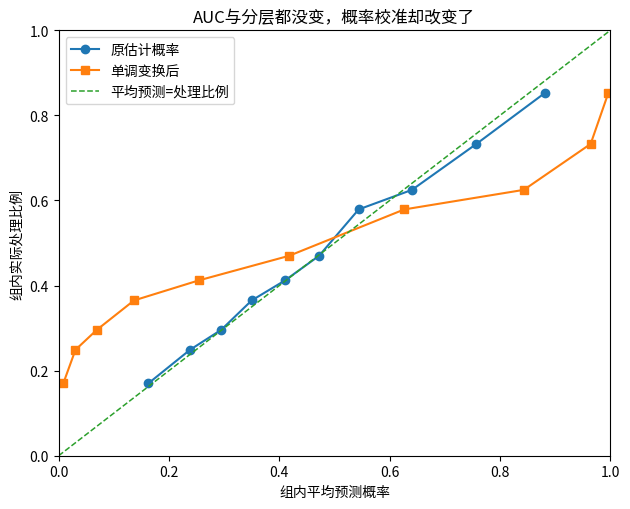

In [19]:
validation_bins = quantile_strata(validation_scores["rich"], 10)
np.testing.assert_array_equal(validation_bins, quantile_strata(sharpened_validation, 10))
calibration = pd.DataFrame({
    "层": validation_bins, "T": validation_design["T"].to_numpy(),
    "原估计概率": validation_scores["rich"], "单调变换后": sharpened_validation,
}).groupby("层").mean()

fig, ax = plt.subplots(figsize=(6.4, 5.2))
for label, marker in [("原估计概率", "o"), ("单调变换后", "s")]:
    ax.plot(calibration[label], calibration["T"], marker=marker, label=label)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.1, label="平均预测=处理比例")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="组内平均预测概率", ylabel="组内实际处理比例",
       title="AUC与分层都没变，概率校准却改变了")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

### 2. 观察到的变量完全平衡，能排除未测混杂吗？

再设相互独立的二元变量 $C,U$，各有一半概率取 1。$C$ 可观察，$U$ 没有被记录。完整机制为：

$$
P(T=1\mid C,U)=0.1+0.2C+0.5U,\qquad
Y=10+3C+8U+2T+\varepsilon.
$$

对未观察的 $U$ 求平均，真实的观察变量评分为

$$
e_C(C)=P(T=1\mid C)=0.35+0.2C.
$$

即使把这个真实 $e_C$ 直接交给分析者，按两个评分水平分层也只能平衡 $C$，不能消除 $U$ 引起的混杂。下面把可用的计算与“额外知道 $U$ 的模拟参考”分开列出。这个反例对应 Ding 对“平衡性质不需要可忽略性”和“未测共同原因”的区分。[1，定理 11.3、第 10.3.2、16.1 节]

参考实现：

In [20]:
rng_hidden = np.random.default_rng(SEED_HIDDEN)
n_hidden = 12000
c_hidden = rng_hidden.binomial(1, 0.5, n_hidden)
u_hidden = rng_hidden.binomial(1, 0.5, n_hidden)
p_complete = 0.1+0.2*c_hidden+0.5*u_hidden
z_hidden = rng_hidden.binomial(1, p_complete)
y_hidden = 10+3*c_hidden+8*u_hidden+2*z_hidden+rng_hidden.normal(0, 1, n_hidden)

# 分析者可用的数据不含 U，也不含完整机制的评分。
observed_hidden = pd.DataFrame({"C": c_hidden, "T": z_hidden, "Y": y_hidden})
g_observed = quantile_strata(0.35+0.2*observed_hidden["C"].to_numpy(), 10)
observed_estimate, _ = stratified_difference(observed_hidden["T"], observed_hidden["Y"], g_observed)
observed_balance, _ = balance_diagnostics(observed_hidden[["C"]], z_hidden, g_observed)

# 仅在模拟审计时才查看 U；这部分不是可用于真实分析的估计步骤。
audit_features = pd.DataFrame({"C": c_hidden, "U（仅模拟可见）": u_hidden})
audit_observed, _ = balance_diagnostics(audit_features, z_hidden, g_observed)
g_complete = quantile_strata(p_complete, 10)
complete_estimate, _ = stratified_difference(z_hidden, y_hidden, g_complete)
audit_complete, _ = balance_diagnostics(audit_features, z_hidden, g_complete)

display(pd.DataFrame({
    "按可观察C的真实评分分层": [observed_estimate,
                          observed_balance.loc["C", "分层后SMD"],
                          audit_observed.loc["U（仅模拟可见）", "分层后SMD"]],
    "额外知道U（模拟参考）": [complete_estimate,
                          audit_complete.loc["C", "分层后SMD"],
                          audit_complete.loc["U（仅模拟可见）", "分层后SMD"]],
}, index=["ATE估计（总体真值=2）", "C的分层后SMD", "U的分层后SMD"]).round(4))
np.testing.assert_allclose(observed_balance.loc["C", "分层后SMD"], 0, atol=1e-12)

,按可观察C的真实评分分层,额外知道U（模拟参考）
ATE估计（总体真值=2）,6.1572,2.0163
C的分层后SMD,0.0000,0.0000
U的分层后SMD,1.1988,0.0000


$C$ 在每层都取同一个值，所以它的分层后差值精确为零，效应却仍明显偏离 2。这里既没有估计评分的误差，也没有粗分层误差；问题是给定 $C$ 后，处理仍与包含 $U$ 的潜在结局相关。

这个结果不否定倾向评分的平衡性质，而是说明它的范围：对已选定的 $X$ 建模，只能检查这些观察变量能支持的比较，不能凭空补回没有测量的信息。

## 小结

倾向评分把处理分配机制压缩成一个概率。要把它用于因果分析，先得选对处理前调整变量，再检查评分模型、分层人数和协变量分布。真实评分的平衡定理、估计评分的有限样本表现、无未测混杂假设，是三个不同的问题。

本篇用分层实现调整：先比较层内两组，再对全体人群的层比例求平均。只看 AUC、只看原变量均值、只看一个汇总平衡点，都可能漏掉问题。层数也不能固定地当成“五层一定够”或“越多越好”。

下一篇保留同一目标，改用逆概率加权来组织比较，并进一步讨论权重、有效样本量和重叠。

## 参考资料与本篇改写范围

[1] Peng Ding. *A First Course in Causal Inference*. 上传文件《因果推断.pdf》，arXiv:2305.18793v2，2023-10-03。主要参考第 11.1 节（定义、降维、分层及推断限制）、第 11.3 节（平衡性质与诊断），并联系第 10.3.2、16.1 节的未测混杂讨论。正文页 153–156、163–165，对应该附件 PDF 页 179–182、189–191。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 上传文件《CausalML_book_2022.pdf》，扉页版本为 0.1.2，2026-05-03。主要参考第 5.3–5.4 节（评分与条件化），第 11.3 节（控制变量的角色）。正文页 140–144，对应 PDF 页 150–154。

[3] statsmodels 官方接口文档，GLM、GLM.fit 与 GLM.predict。本篇使用二项 GLM 的概率预测，不使用其处理系数来估计 ATE。接口说明：`https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.html`。

计算范围说明：本篇模拟、AUC/Brier 对照与 SMD 的固定分母约定是为实现上述学习流程新增的教学内容。没有复现原书 NHANES 的实证数值，也没有复制图 11.2 的置信区间。平衡检查按 Ding 定理 11.3 解释为关于所测 $X,T$ 的诊断；第二本第 5.3 节在已知随机化概率下讨论试验检查，本篇不把这种检查直接解释为观察性研究“无未测混杂”的检验。